# PRACTICE EMAIL SPAM CLASSIFICATION.

1. Bộ dữ liệu được sử dụng trong dự án được thu thập từ nền tảng Kaggle, một trong những kho dữ liệu phổ biến dành cho nghiên cứu và thực hành Machine Learning. Bộ dữ liệu bao gồm nhiều email đã được gán nhãn sẵn thành hai nhóm là Spam và Ham, phục vụ cho bài toán phân loại văn bản.

Trong đó:

- Spam: Các email quảng cáo, tiếp thị, lừa đảo hoặc nội dung không mong muốn.
- Ham: Các email hợp lệ, mang tính trao đổi thông tin bình thường giữa người gửi và người nhận.

Mỗi bản ghi trong tập dữ liệu chứa nội dung email dưới dạng văn bản cùng với nhãn phân loại tương ứng. Điều này cho phép xây dựng các mô hình học máy để học các đặc trưng của từng loại email và tự động đưa ra dự đoán cho các email mới.

2. ngữ cảnh và mục tiêu bài toán.

Trong thực tế, một người dùng cá nhân có thể nhận được hàng chục đến hàng trăm email mỗi ngày. Việc phải đọc và phân loại thủ công từng email gây tốn thời gian và có thể dẫn đến việc bỏ sót các thư quan trọng hoặc mở nhầm các email lừa đảo.

Do đó, hệ thống phân loại Spam/Ham được xây dựng nhằm hỗ trợ:

- Tự động phát hiện các email rác trước khi người dùng đọc.
- Giảm thời gian xử lý và quản lý hộp thư.
- Hạn chế nguy cơ bị lừa đảo thông qua các email giả mạo hoặc chứa liên kết độc hại.
- Nâng cao trải nghiệm sử dụng email cho người dùng cá nhân.

Trong dự án này, nội dung email sẽ được xử lý bằng các kỹ thuật tiền xử lý văn bản và chuyển đổi thành dữ liệu số để huấn luyện các mô hình Machine Learning. Các mô hình sau đó sẽ học cách nhận biết sự khác biệt giữa email Spam và Ham, từ đó dự đoán chính xác loại của một email mới.

# Các bước thực hiện.

1. Khám phá dữ liệu EDA:
   - Tổng quan dữ liệu
   - Kiểm tra giá trị thiếu
   - Kiểm tra dữ liệu trùng lặp
   - Phân bố lớp Spam/Ham
   - Phân tích độ dài email
   - Phân tích số lượng từ
   - Phân tích ký tự đặc biệt
   - Phân tích từ xuất hiện nhiều nhất

2. Xử lý dữ liệu (Preprocessing):
   - Chuẩn hóa văn bản
   - Loại bỏ HTML Tags, URL, dấu câu và ký tự đặc biệt, Stopwords
   - So sánh trước và sau tiền xử lý

3. Feature Engineering.
   - Text Length.
   - Word Count.
   - Exclamation Count.
   - Dollar Count.
   - Uppercase Ratio.
   - URL Count.
   - Compare features

4. Trích xuất đặc trưng (Feature Extraction):
   - TF-IDF Vectorization

5. Chia dữ liệu (Train/Test).

6. Model training:
   - Logistic regression.
   - naive bayes.
   - Support vector machine.

7. Model Evaluation:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion Matrix

8. Dự đoán email mới.

9. Save model and deployment.




In [3]:
# =========================
# 0. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import re
import string
import pickle
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import wordcloud as WordCloud
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

#model base build from scratch
from models.logictisregression import LogisticRegressionM
from models.naive_bayes import MultinomialNaiveBayes
from models.svm import LinearSVM
from utils.metrics import classification_report

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hovan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("data/email_spam.csv", encoding="latin1")

df_EDA = df.copy()

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Exploratory Data Analysis (EDA)

## Dataset Overview


In [5]:
print("Kích thước dữ liệu:", df_EDA.shape)
df_EDA.info()

Kích thước dữ liệu: (5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df_EDA.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


total rows: 5572 , total columns: 5


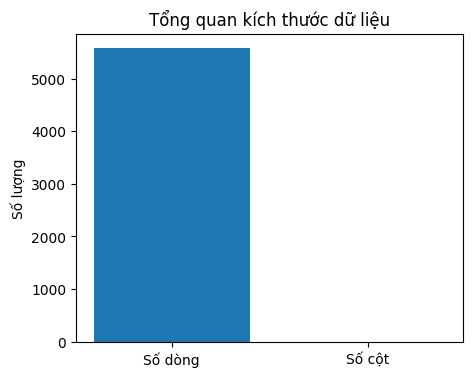

In [7]:
print("total rows:",df_EDA.shape[0], ", total columns:",df_EDA.shape[1])
plt.figure(figsize=(5, 4))
plt.bar(["Số dòng", "Số cột"], [df_EDA.shape[0], df_EDA.shape[1]])
plt.title("Tổng quan kích thước dữ liệu")
plt.ylabel("Số lượng")
plt.show()

## Missing value and duplicate 

In [8]:
missing_values = df_EDA.isnull().sum()
missing_values

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

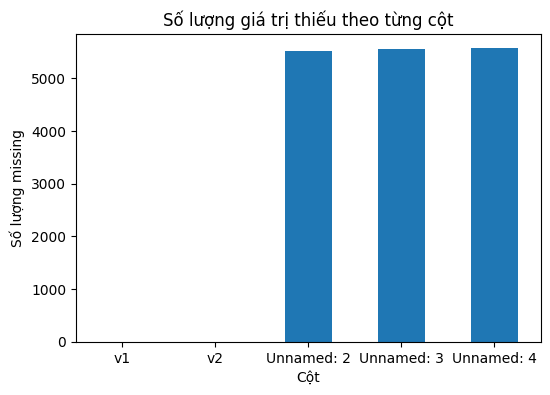

In [9]:
plt.figure(figsize=(6, 4))
missing_values.plot(kind="bar")
plt.title("Số lượng giá trị thiếu theo từng cột")
plt.xlabel("Cột")
plt.ylabel("Số lượng missing")
plt.xticks(rotation=0)
plt.show()

In [10]:
duplicate_count = df_EDA.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

Số dòng trùng lặp: 403


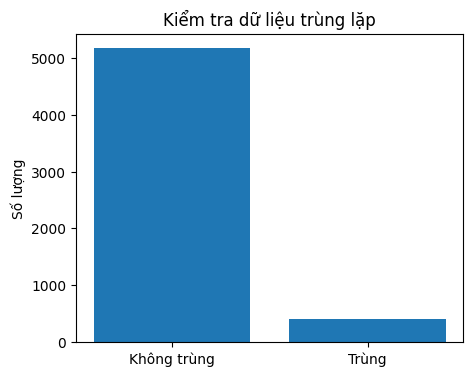

In [11]:
plt.figure(figsize=(5, 4))
plt.bar(["Không trùng", "Trùng"], [len(df_EDA) - duplicate_count, duplicate_count])
plt.title("Kiểm tra dữ liệu trùng lặp")
plt.ylabel("Số lượng")
plt.show()

In [12]:
df_EDA = df_EDA.drop_duplicates()
df = df.drop_duplicates()
print("Kích thước sau khi xóa trùng:", df_EDA.shape)

Kích thước sau khi xóa trùng: (5169, 5)


## label distribution

In [13]:
label_counts = df_EDA["v1"].value_counts()
label_counts

v1
ham     4516
spam     653
Name: count, dtype: int64

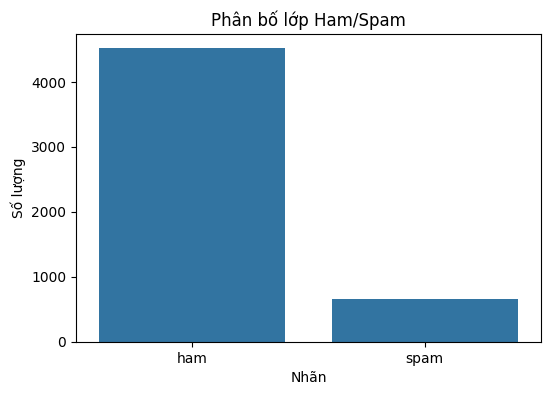

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_EDA, x="v1")
plt.title("Phân bố lớp Ham/Spam")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.show()

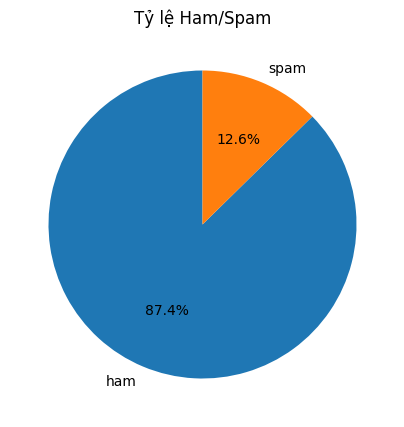

In [15]:
plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Tỷ lệ Ham/Spam")
plt.show()

## Email length Analysis

In [16]:
df_EDA["text_length"] = df_EDA["v2"].apply(len)

df_EDA.groupby("v1")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
v1,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


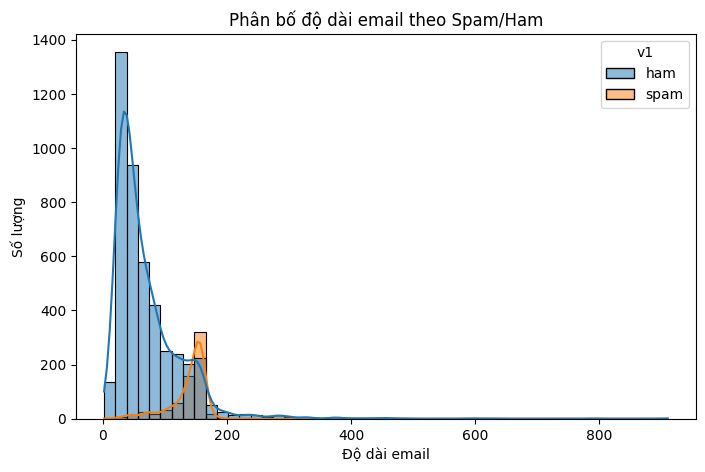

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_EDA, x="text_length", hue="v1", bins=50, kde=True)
plt.title("Phân bố độ dài email theo Spam/Ham")
plt.xlabel("Độ dài email")
plt.ylabel("Số lượng")
plt.show()

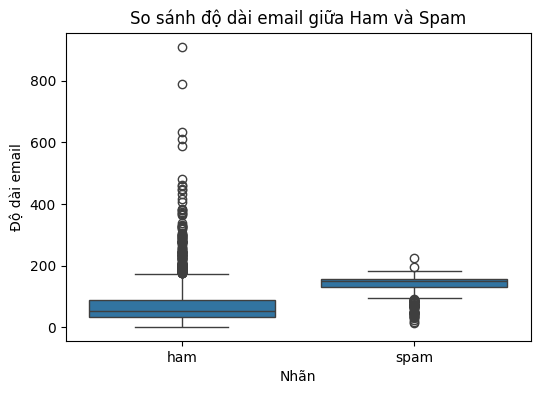

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="text_length")
plt.title("So sánh độ dài email giữa Ham và Spam")
plt.xlabel("Nhãn")
plt.ylabel("Độ dài email")
plt.show()

## Word Count Analysis

In [19]:
df_EDA["word_count"] = df_EDA["v2"].apply(lambda x: len(str(x).split()))

df_EDA.groupby("v1")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
v1,,,,,,,,
ham,4516.0,14.134632,11.116240,1.0,7.0,11.0,18.0,171.0
spam,653.0,23.681470,5.967672,2.0,22.0,25.0,28.0,35.0


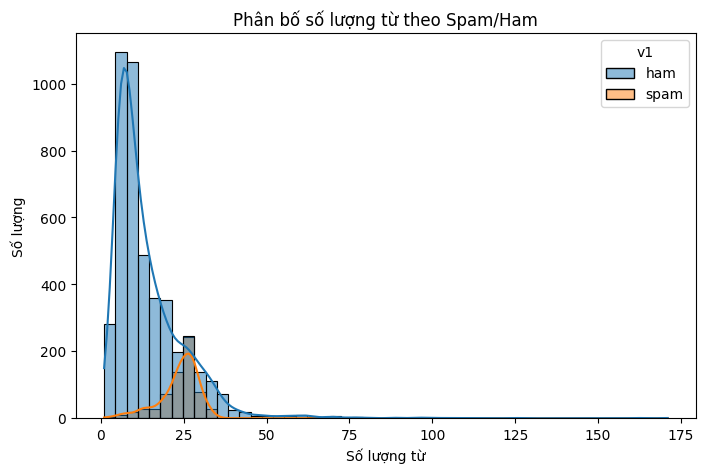

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_EDA, x="word_count", hue="v1", bins=50, kde=True)
plt.title("Phân bố số lượng từ theo Spam/Ham")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng")
plt.show()

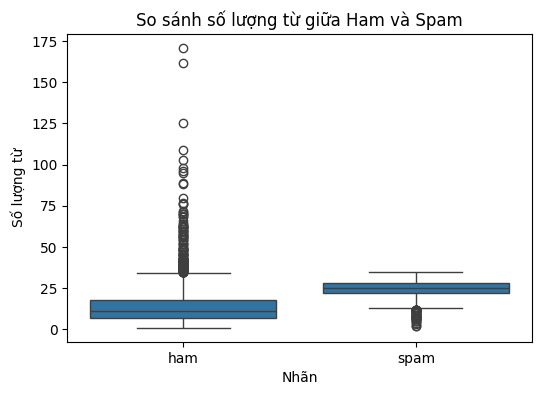

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="word_count")
plt.title("So sánh số lượng từ giữa Ham và Spam")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng từ")
plt.show()

## special characters analysis

In [22]:
df_EDA["exclamation_count"] = df_EDA["v2"].apply(lambda x: str(x).count("!"))
df_EDA["dollar_count"] = df_EDA["v2"].apply(lambda x: str(x).count("$"))
df_EDA["question_count"] = df_EDA["v2"].apply(lambda x: str(x).count("?"))

special_summary = df_EDA.groupby("v1")[[
    "exclamation_count",
    "dollar_count",
    "question_count"
]].mean()

special_summary

,exclamation_count,dollar_count,question_count
v1,,,
ham,0.174712,0.004207,0.292958
spam,0.693721,0.006126,0.243492


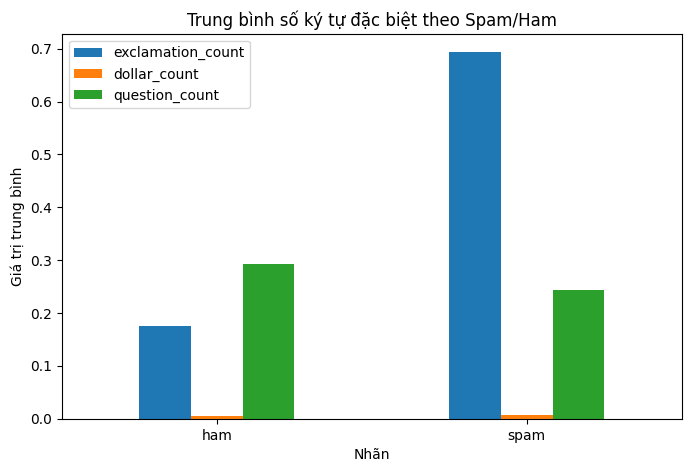

In [23]:
special_summary.plot(kind="bar", figsize=(8, 5))
plt.title("Trung bình số ký tự đặc biệt theo Spam/Ham")
plt.xlabel("Nhãn")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=0)
plt.show()

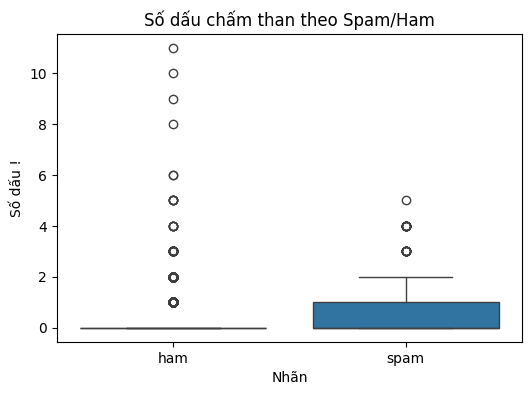

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_EDA, x="v1", y="exclamation_count")
plt.title("Số dấu chấm than theo Spam/Ham")
plt.xlabel("Nhãn")
plt.ylabel("Số dấu !")
plt.show()

## Analyze the most frequently appearing words.

In [25]:
ham_words = " ".join(df_EDA[df_EDA["v1"] == "ham"]["v2"]).lower().split()
spam_words = " ".join(df_EDA[df_EDA["v1"] == "spam"]["v2"]).lower().split()

ham_common = Counter(ham_words).most_common(20)
spam_common = Counter(spam_words).most_common(20)

ham_common_df = pd.DataFrame(ham_common, columns=["word", "count"])
spam_common_df = pd.DataFrame(spam_common, columns=["word", "count"])

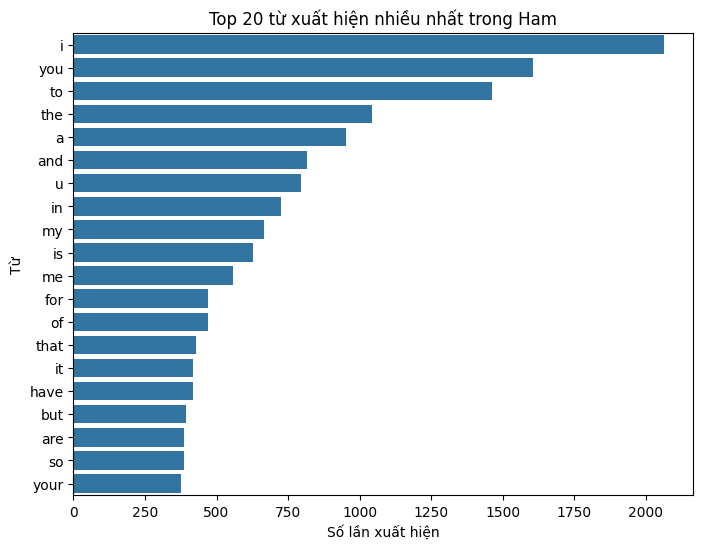

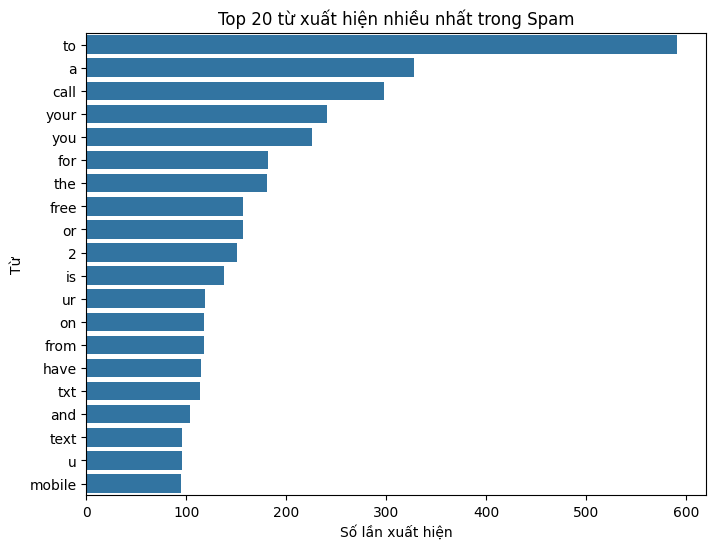

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(data=ham_common_df, x="count", y="word")
plt.title("Top 20 từ xuất hiện nhiều nhất trong Ham")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=spam_common_df, x="count", y="word")
plt.title("Top 20 từ xuất hiện nhiều nhất trong Spam")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ")
plt.show()

# Preprocessing

## standardize text


In [27]:
df.rename(
    columns={
        "v1": "label",
        "v2": "message"
    },
    inplace=True
)

df.head()

df.drop(
    columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],
    inplace=True,
    errors="ignore"
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [28]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Remove HTML tags, URLs, punctuation, and special characters, Stopwords

In [29]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()                         

    text = re.sub(r"<.*?>", " ", text)             

    text = re.sub(r"http\S+|www\S+", " ", text)     

    text = re.sub(r"[^a-zA-Z\s]", " ", text)        

    words = text.split()

    words = [word for word in words
             if word not in stop_words]             

    return " ".join(words)

df["message_clean"] = df["message"].apply(clean_text)

In [30]:
df

,label,message,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,nd time tried contact u u pound prize claim ea...
5568,0,Will Ì_ b going to esplanade fr home?,b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood suggestions
5570,0,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...


## Compare before and after preprocess

In [31]:
comparison_df = df[["message", "message_clean"]]

comparison_df.head(10)

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


In [32]:
for i in range(3):
    print("Before:")
    print(df["message"].iloc[i])

    print("\nAfter:")
    print(df["message_clean"].iloc[i])

    print("-" * 80)

Before:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

After:
go jurong point crazy available bugis n great world la e buffet cine got amore wat
--------------------------------------------------------------------------------
Before:
Ok lar... Joking wif u oni...

After:
ok lar joking wif u oni
--------------------------------------------------------------------------------
Before:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

After:
free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
--------------------------------------------------------------------------------


# Feature Engineering.

In [33]:
def uppercase_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)


def url_count(text):
    return len(re.findall(r"http\S+|www\S+", str(text)))

In [34]:
df["message_length"] = df["message"].apply(len)

df["message_word_count"] = df["message"].apply(
    lambda x: len(str(x).split())
)

df["exclamation_count"] = df["message"].apply(
    lambda x: str(x).count("!")
)

df["dollar_count"] = df["message"].apply(
    lambda x: str(x).count("$")
)

df["uppercase_ratio"] = df["message"].apply(uppercase_ratio)

df["url_count"] = df["message"].apply(url_count)

In [35]:


feature_cols = [
    "message_length",
    "message_word_count",
    "exclamation_count",
    "dollar_count",
    "uppercase_ratio",
    "url_count"
]

scaled_df = df.copy()

scaler = MinMaxScaler()

scaled_df[feature_cols] = scaler.fit_transform(
    scaled_df[feature_cols]
)

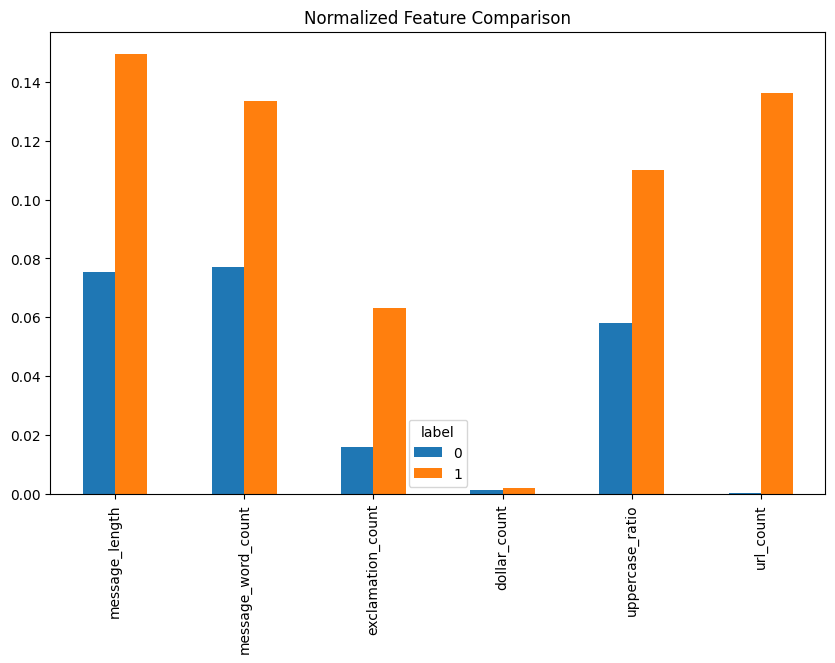

In [36]:
feature_summary = scaled_df.groupby("label")[
    feature_cols
].mean()

feature_summary.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Normalized Feature Comparison")
plt.show()

# Feature Extraction

## Transform data

In [37]:
X_text = df["message_clean"]
y = df["label"]

tfidf = TfidfVectorizer(
    max_features=3000
)

X_tfidf = tfidf.fit_transform(X_text)

In [38]:
print(X_tfidf.shape)

(5169, 3000)


In [39]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aah' 'aathi' 'abi' 'ability' 'abiola' 'abj' 'able' 'abt' 'abta' 'aburo'
 'ac' 'academic' 'acc' 'accept' 'access' 'accident' 'accidentally'
 'accordingly' 'account' 'ache' 'acl' 'across' 'action' 'activate'
 'actually' 'ad' 'add' 'added' 'addie' 'address' 'admirer' 'adore' 'adult'
 'advance' 'advice' 'ae' 'affairs' 'afraid' 'aft' 'afternoon' 'aftr' 'age'
 'ages' 'ago' 'ah' 'aha' 'ahead' 'ahmad' 'aight' 'aint']


In [40]:
word_scores = X_tfidf.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    "word": feature_names,
    "score": word_scores
})

tfidf_df = tfidf_df.sort_values(
    by="score",
    ascending=False
)

In [41]:
top_words = tfidf_df.head(20)

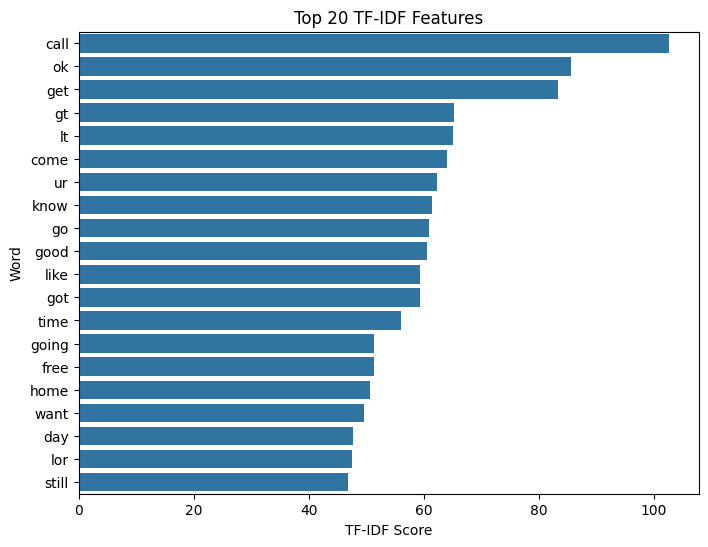

In [42]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=top_words,
    x="score",
    y="word"
)

plt.title("Top 20 TF-IDF Features")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")

plt.show()

In [43]:
extra_features = df[[
    "message_length",
    "message_word_count",
    "exclamation_count",
    "dollar_count",
    "uppercase_ratio",
    "url_count"
]].values

In [44]:
X = hstack([
    X_tfidf,
    extra_features
])

In [45]:
print(X.shape)

(5169, 3006)


# Train / test split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
train_dist = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percent": y_train.value_counts(normalize=True) * 100
})

test_dist = pd.DataFrame({
    "Count": y_test.value_counts(),
    "Percent": y_test.value_counts(normalize=True) * 100
})

print("TRAIN SET")
print(train_dist)

print("\nTEST SET")
print(test_dist)

TRAIN SET
       Count    Percent
label                  
0       3613  87.376058
1        522  12.623942

TEST SET
       Count    Percent
label                  
0        903  87.330754
1        131  12.669246


C:\Users\hovan\AppData\Local\Temp\ipykernel_2236\1704482217.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Ham", "Spam"])
C:\Users\hovan\AppData\Local\Temp\ipykernel_2236\1704482217.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Ham", "Spam"])


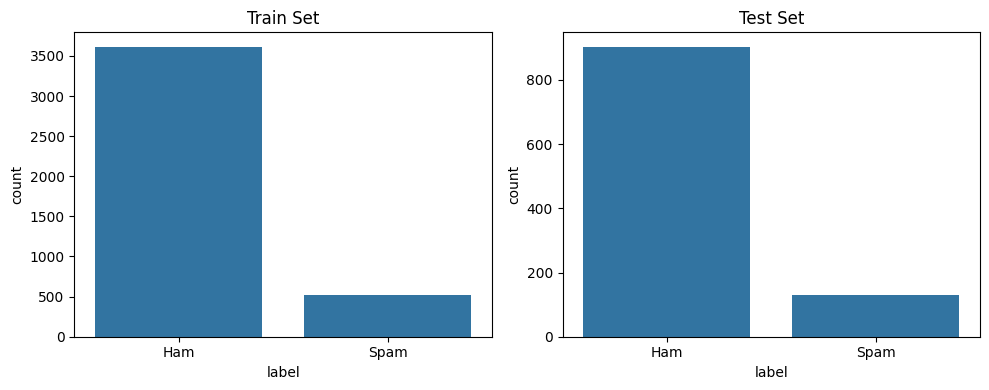

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Train Set")
axes[0].set_xticklabels(["Ham", "Spam"])

sns.countplot(
    x=y_test,
    ax=axes[1]
)

axes[1].set_title("Test Set")
axes[1].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.show()

# Model Training

## model logistic

## Logistic Regression

In [49]:
lr_model = LogisticRegressionM(learning_rate=0.5, n_iters=2000, threshold=0.5)
lr_model.fit(X_train, y_train)

  Epoch     0/2000 | loss = 0.6931


c:\Users\hovan\OneDrive\Desktop\practice1\models\logictisregression.py:9: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))


  Epoch   200/2000 | loss = 2.9068
  Epoch   400/2000 | loss = 2.9123
  Epoch   600/2000 | loss = 2.9176
  Epoch   800/2000 | loss = 2.9068
  Epoch  1000/2000 | loss = 3.0050
  Epoch  1200/2000 | loss = 8.2679
  Epoch  1400/2000 | loss = 2.9012
  Epoch  1600/2000 | loss = 2.8975
  Epoch  1800/2000 | loss = 2.9068


(array([-0.06120221, -0.12201913, -0.03150728, ..., -0.40649166,
         0.84967773, 10.5126224 ]),
 -62.760387115614314)

In [50]:
print("=== Logistic Regression – Classification Report ===")
lr_model.classification_Report(X_test, y_test)

=== Logistic Regression – Classification Report ===

            precision     recall   f1-score    support

ham (0)          1.00       0.36       0.52        903
spam (1)         0.18       0.99       0.31        131

accuracy                               0.44       1034
macro avg        0.59       0.67       0.42       1034



## Naive Bayes

In [51]:
# Naive Bayes nhận count/TF-IDF dense array
nb_model = MultinomialNaiveBayes(alpha=1)
nb_model.fit(X_train, y_train)

In [52]:
print("=== Naive Bayes – Classification Report ===")
nb_model.classification_Report(X_test, y_test)

=== Naive Bayes – Classification Report ===

            precision     recall   f1-score    support

ham (0)          0.95       1.00       0.97        903
spam (1)         0.97       0.64       0.77        131

accuracy                               0.95       1034
macro avg        0.96       0.82       0.87       1034



## Support Vector Machine

In [53]:
svm_model = LinearSVM(learning_rate=0.01, lambda_param=0.001, epochs=3000)
svm_model.fit(X_train, y_train)

  Epoch     0/3000 | loss = 1.0001
  Epoch   500/3000 | loss = 10.0205
  Epoch  1000/3000 | loss = 2.4245
  Epoch  1500/3000 | loss = 5.7257
  Epoch  2000/3000 | loss = 2.5975
  Epoch  2500/3000 | loss = 4.9436


In [54]:
print("=== SVM – Classification Report ===")
svm_model.classification_Report(X_test, y_test)

=== SVM – Classification Report ===

            precision     recall   f1-score    support

ham (0)          1.00       0.04       0.08        903
spam (1)         0.13       1.00       0.23        131

accuracy                               0.16       1034
macro avg        0.57       0.52       0.16       1034



# Model Evaluation

## Confusion Matrix & So sánh các mô hình

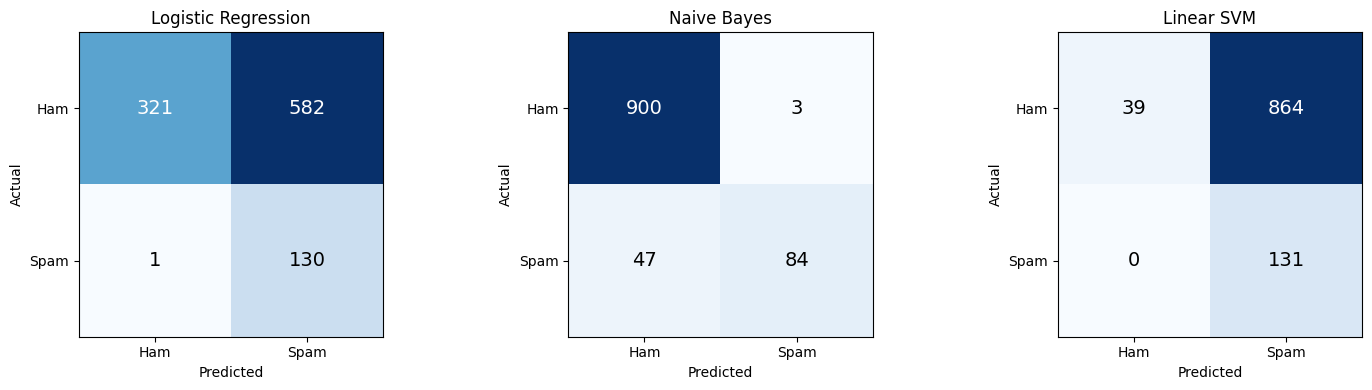

In [55]:
from utils.metrics import confusion_matrix as cm_scratch

models = {
    "Logistic Regression": lr_model,
    "Naive Bayes":         nb_model,
    "Linear SVM":          svm_model,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = cm_scratch(y_test, y_pred, labels=[0, 1])

    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Ham", "Spam"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Ham", "Spam"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=14)

plt.tight_layout()
plt.show()


            precision     recall   f1-score    support

ham (0)          1.00       0.36       0.52        903
spam (1)         0.18       0.99       0.31        131

accuracy                               0.44       1034
macro avg        0.59       0.67       0.42       1034


            precision     recall   f1-score    support

ham (0)          0.95       1.00       0.97        903
spam (1)         0.97       0.64       0.77        131

accuracy                               0.95       1034
macro avg        0.96       0.82       0.87       1034


            precision     recall   f1-score    support

ham (0)          1.00       0.04       0.08        903
spam (1)         0.13       1.00       0.23        131

accuracy                               0.16       1034
macro avg        0.57       0.52       0.16       1034

                     Accuracy  Precision  Recall  F1-score
Logistic Regression    0.4362     0.5897  0.6739    0.4163
Naive Bayes            0.9516     0.9579  0.8

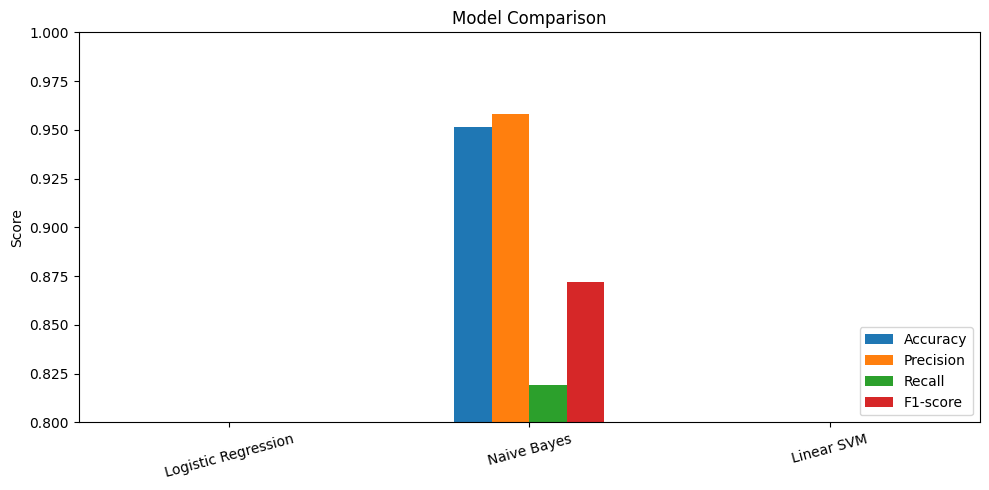

In [56]:
# So sánh Accuracy, Precision, Recall, F1 giữa 3 mô hình
from utils.metrics import classification_report

summary = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(np.array(y_test), y_pred,
                                  target_names=["ham (0)", "spam (1)"])
    summary[name] = {
        "Accuracy":  report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall":    report["macro avg"]["recall"],
        "F1-score":  report["macro avg"]["f1-score"],
    }

summary_df = pd.DataFrame(summary).T
print(summary_df.round(4))

# Bar chart so sánh
summary_df.plot(kind="bar", figsize=(10, 5), ylim=(0.8, 1.0))
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()